# Combined NeurIPS submission plots

This notebook consolidates the figures from `final_submission_plots.ipynb` and `adversarial_worst_case.ipynb` into one executable document. The source notebooks remain unchanged. Each section retains its original data validation, plotting style, output paths, and figure filenames.

## Final NeurIPS submission figures

This notebook produces the paper plots for the two-layer compression story: an LLM token table first maps source bytes to token IDs, and a predictive arithmetic coder then maps those IDs to bits. It reads saved experiment artifacts without rerunning model inference.

Outputs are written to `artifacts/figures/neurips/final/` as vector PDF and 300-DPI PNG files. Assertions make every plotted comparison auditable.

In [1]:
from pathlib import Path
import json, math
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate/'pyproject.toml').exists(): return candidate
    raise FileNotFoundError('Could not locate repository root')
ROOT=find_repo_root(); FIGURE_DIR=ROOT/'artifacts/figures/neurips/final'; FIGURE_DIR.mkdir(parents=True,exist_ok=True)
COLORS={'blue':'#0072B2','orange':'#D55E00','green':'#009E73','purple':'#CC79A7','ink':'#202124','muted':'#6B7280','light':'#D1D5DB','paper':'#FFFFFF'}
mpl.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','font.family':'DejaVu Sans','font.size':8.5,'axes.titlesize':9.5,'axes.titleweight':'bold','axes.labelsize':8.5,'xtick.labelsize':7.5,'ytick.labelsize':7.5,'legend.fontsize':7.4,'axes.spines.top':False,'axes.spines.right':False,'axes.edgecolor':COLORS['ink'],'axes.linewidth':0.7,'pdf.fonttype':42,'ps.fonttype':42,'savefig.bbox':'tight','savefig.pad_inches':0.03})
def save_figure(fig,stem):
    pdf=FIGURE_DIR/f'{stem}.pdf'; png=FIGURE_DIR/f'{stem}.png'; fig.savefig(pdf); fig.savefig(png,dpi=300); print('Saved',pdf.relative_to(ROOT)); print('Saved',png.relative_to(ROOT))

### Load and validate the matched experiments

The full-vocabulary adversarial sequences comprise three completed 10,000-token runs. They were generated once and replayed under an occurring-token mask, then scored with the actual arithmetic coder. The text8 controls match model, context, retained context, KV-cache policy, and arithmetic coding. The one-byte stress test is the earlier verified 1,000-token run; the beam panel remains a clearly labeled 32-token diagnostic.

In [2]:
ADV_DIR=ROOT/'artifacts/runs/paper-evaluation/full_vocab_n10000'
ASCII_DIR=ROOT/'artifacts/runs/adversarial/qwen_05b_ascii_bytes_n1000/full'
PIPELINE_RESULTS=ROOT/'artifacts/runs/current/compression_results.json'
adv={v:json.loads((ADV_DIR/v/'results.json').read_text()) for v in ('full','occurring')}
ascii_results=json.loads((ASCII_DIR/'results.json').read_text()); ascii_check=json.loads((ASCII_DIR/'compression_verification.json').read_text()); coding=json.loads((ADV_DIR/'arithmetic_payloads.json').read_text()); pipeline=json.loads(PIPELINE_RESULTS.read_text())
for f,m in zip(adv['full']['runs'],adv['occurring']['runs']):
    assert f['token_ids']==m['token_ids'] and f['decoded_text_round_trips'] and m['decoded_text_round_trips']
    # The replay is authoritative for scores: generation checkpoints in this preliminary artifact reset the retained context too aggressively.
assert adv['occurring']['metadata']['mask_application']=='post-hoc rescoring' and adv['occurring']['metadata']['same_token_ids_as_full'] is True
assert len(adv['full']['runs'])==len(adv['occurring']['runs'])==3 and all(len(r['token_ids'])==10000 for r in adv['full']['runs'])
assert len(coding['runs'])==6 and {r['policy'] for r in coding['runs']}=={'full','occurring'}
assert ascii_check['token_round_trip'] and ascii_check['byte_round_trip'] and ascii_check['serialized_artifact_token_round_trip'] and ascii_check['serialized_artifact_byte_round_trip']
model_name=adv['full']['metadata']['model_name']; vocab_size=adv['full']['runs'][0]['summary']['candidate_size']; fixed_id_bits=math.ceil(math.log2(vocab_size))
assert model_name=='Qwen/Qwen2.5-0.5B' and vocab_size==151643 and fixed_id_bits==18

def find_text8(reduce):
    hits=[]
    for entry in pipeline.values():
        c=entry.get('compression',{}); a=c.get('args',{})
        if (Path(str(a.get('input_path',''))).name=='text8' and a.get('model_name')==model_name and a.get('first_n_tokens')==100000 and a.get('context_length')==1000 and a.get('retain_tokens')==100 and a.get('use_kv_cache') is True and a.get('batch_size')==16 and a.get('encoding')=='AC' and a.get('reduce_tokens') is reduce and a.get('lora_path') is None): hits.append(c)
    assert len(hits)==1; return hits[0]
text8={'full':find_text8(False),'occurring':find_text8(True)}
assert text8['full']['original_size_bytes']==text8['occurring']['original_size_bytes']

In [3]:
def adv_rate(field):
    return np.array([100*(fixed_id_bits-sum(x/math.log(2) for x in r[field]))/(8*r['decoded_utf8_size_bytes']) for r in adv['occurring']['runs']])
def adv_fixed():
    return np.array([100*fixed_id_bits*r['summary']['total_tokens']/(8*r['decoded_utf8_size_bytes']) for r in adv['full']['runs']])
def text8_metrics(v):
    r=text8[v]; n=r['args']['first_n_tokens']; b=r['args']['batch_size']; raw=8*r['original_size_bytes']
    return {'fixed':100*n*fixed_id_bits/raw,'floor':100*(b*fixed_id_bits+r['entropy'])/raw,'payload':100*r['arithmetic_code_size_bytes']/r['original_size_bytes'],'total':100*r['final_size_bytes']/r['original_size_bytes'],'bitmap':100*r['bitmap_size_bytes']/r['original_size_bytes']}
tm={v:text8_metrics(v) for v in ('full','occurring')}
coding_total={v:np.array([100*r['payload_plus_seed_and_dictionary_ratio'] for r in coding['runs'] if r['policy']==v]) for v in ('full','occurring')}
ac=ascii_check['compression']; raw=ac['original_size_bytes']; n=ascii_results['runs'][0]['summary']['total_tokens']
ascii_floor=100*(fixed_id_bits+ac['entropy'])/(8*raw); ascii_fixed=100*n*fixed_id_bits/(8*raw); ascii_payload=100*ac['arithmetic_code_size_bytes']/raw; ascii_total=100*ac['final_size_bytes']/raw; ascii_serial=ascii_check['serialized_file_ratio_percent']
summary=pd.DataFrame([{'condition':'Typical text8','fixed':tm['full']['fixed'],'surprisal':tm['full']['floor'],'total':tm['full']['total'],'serialized':np.nan},{'condition':'Full-vocabulary adversary','fixed':adv_fixed().mean(),'surprisal':adv_rate('model_log_probabilities').mean(),'total':coding_total['full'].mean(),'serialized':np.nan},{'condition':'One-byte adversary','fixed':ascii_fixed,'surprisal':ascii_floor,'total':ascii_total,'serialized':ascii_serial}])
masking=pd.DataFrame([{'dataset':'Typical text8','full':tm['full']['floor'],'occurring':tm['occurring']['floor']},{'dataset':'Adversarial worst case','full':adv_rate('model_log_probabilities').mean(),'occurring':adv_rate('masked_log_probabilities').mean()}])
display(summary.round(3)); display(masking.round(3)); print('Full-vocabulary AC total:',round(coding_total['full'].mean(),3),'%'); print('One-byte AC payload:',round(ascii_payload,3),'%')

,condition,fixed,surprisal,total,serialized
0,Typical text8,42.241,11.631,14.405,NaN
1,Full-vocabulary adversary,31.754,47.374,31.677,NaN
2,One-byte adversary,225.000,105.337,123.912,155.2


,dataset,full,occurring
0,Typical text8,11.631,11.352
1,Adversarial worst case,47.374,33.946


Full-vocabulary AC total: 31.677 %
One-byte AC payload: 120.412 %


### Main figure: tokenization can buffer or expose predictive failure

Panel **a** separates model surprisal from the realized arithmetic total. For the 10,000-token full-vocabulary runs, finite-frequency quantization clips rare-symbol code lengths near 18 bits, so realized arithmetic size is below the unquantized model surprisal estimate. The one-byte adversary removes tokenizer fertility as a buffer and expands. Panel **b** holds token IDs fixed and changes only mask normalization.

Saved artifacts/figures/neurips/final/layered_compression_robustness.pdf
Saved artifacts/figures/neurips/final/layered_compression_robustness.png


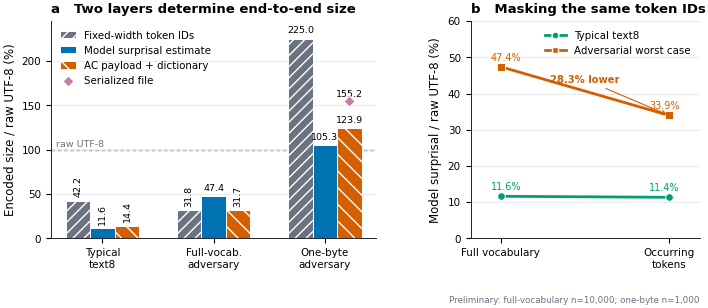

In [4]:
fig,(left,right)=plt.subplots(1,2,figsize=(7.05,3.15),gridspec_kw={'width_ratios':[1.42,1.0]})
conditions=['Typical\ntext8','Full-vocab.\nadversary','One-byte\nadversary']; x=np.arange(3); width=.22
metrics=[('fixed','Fixed-width token IDs',COLORS['muted'],'///'),('surprisal','Model surprisal estimate',COLORS['blue'],''),('total','AC payload + dictionary',COLORS['orange'],'\\\\')]
for off,(col,label,color,hatch) in zip((-1,0,1),metrics):
    vals=summary[col].to_numpy(float); bars=left.bar(x+off*width,vals,width,color=color,edgecolor='white',linewidth=.7,hatch=hatch,label=label,zorder=3)
    for bar,val in zip(bars,vals):
        if np.isfinite(val): left.text(bar.get_x()+bar.get_width()/2,val+4.2,f'{val:.1f}',ha='center',va='bottom',fontsize=6.8,rotation=90 if val<45 else 0)
left.scatter(x[2]+width,summary.loc[2,'serialized'],marker='D',s=31,color=COLORS['purple'],edgecolor='white',linewidth=.7,zorder=5,label='Serialized file'); left.text(x[2]+width,summary.loc[2,'serialized']+5,f"{summary.loc[2,'serialized']:.1f}",ha='center',fontsize=6.8)
left.axhline(100,color=COLORS['ink'],linestyle=(0,(3,2)),linewidth=.9,zorder=1); left.text(-.42,103,'raw UTF-8',fontsize=6.8,color=COLORS['muted'])
left.set(ylim=(0,245),ylabel='Encoded size / raw UTF-8 (%)'); left.set_xticks(x,conditions); left.set_title('a   Two layers determine end-to-end size',loc='left'); left.grid(axis='y',color='#E5E7EB',linewidth=.6,zorder=0); handles, legend_labels = left.get_legend_handles_labels()
legend_map = dict(zip(legend_labels, handles))
legend_order = ['Fixed-width token IDs', 'Model surprisal estimate', 'AC payload + dictionary', 'Serialized file']
left.legend([legend_map[label] for label in legend_order], legend_order, loc='upper left', frameon=False, handlelength=1.5)
styles={'Typical text8':(COLORS['green'],'o'),'Adversarial worst case':(COLORS['orange'],'s')}
for _,row in masking.iterrows():
    color,marker=styles[row['dataset']]; vals=np.array([row['full'],row['occurring']]); right.plot([0,1],vals,color=color,lw=2,marker=marker,markersize=5.5,markeredgecolor='white',markeredgewidth=.7,zorder=3); right.text(.03,vals[0]+1.8,f'{vals[0]:.1f}%',color=color,fontsize=7,ha='center'); right.text(.97,vals[1]+1.8,f'{vals[1]:.1f}%',color=color,fontsize=7,ha='center')
reduction=100*(1-masking.loc[1,'occurring']/masking.loc[1,'full']); right.annotate(f'{reduction:.1f}% lower',xy=(1,masking.loc[1,'occurring']),xytext=(.5,43),ha='center',fontsize=7.2,color=COLORS['orange'],fontweight='bold',arrowprops={'arrowstyle':'->','color':COLORS['orange'],'lw':.8})
right.set(xlim=(-.18,1.18),ylim=(0,60),ylabel='Model surprisal / raw UTF-8 (%)'); right.set_xticks([0,1],['Full vocabulary','Occurring\ntokens']); right.set_title('b   Masking the same token IDs',loc='left'); right.grid(axis='y',color='#E5E7EB',linewidth=.6,zorder=0)
right.legend(handles=[Line2D([0],[0],color=c,marker=m,lw=2,markersize=5,markeredgecolor='white',label=l) for l,(c,m) in styles.items()],loc='upper right',frameon=False)
fig.text(.995,.015,'Preliminary: full-vocabulary n=10,000; one-byte n=1,000',ha='right',fontsize=6.3,color=COLORS['muted']); fig.subplots_adjust(left=.075,right=.995,top=.91,bottom=.22,wspace=.34); save_figure(fig,'layered_compression_robustness'); plt.show()

### Coder-aware attack validation

This compact diagnostic excludes serialized totals because 2,783 fixed bits dominate at only 32 tokens. It compares the model floor with the realized arithmetic payload. This belongs in supplementary material or a short method-validation panel.

Saved artifacts/figures/neurips/final/coder_aware_attack_validation.pdf
Saved artifacts/figures/neurips/final/coder_aware_attack_validation.png


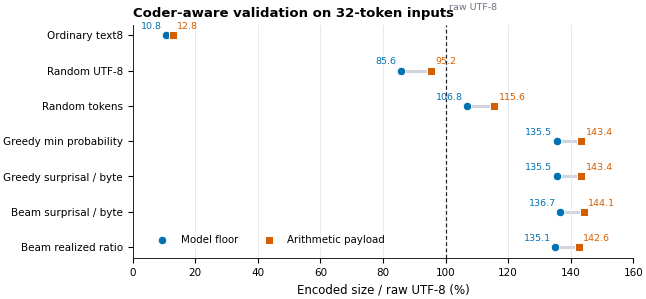

In [5]:
p=json.loads((ROOT/'artifacts/runs/compression-attacks/qwen_05b_ascii_n32_smoke/results.json').read_text()); assert p['metadata']['total_length']==32 and p['metadata']['generation_alphabet']=='ascii-bytes' and p['metadata']['beam_width']==2 and p['metadata']['branch_factor']==4
labels={'ordinary-text8':'Ordinary text8','random-printable-utf8':'Random UTF-8','random-token':'Random tokens','min-probability':'Greedy min probability','surprisal-per-byte':'Greedy surprisal / byte','beam-surprisal-per-byte':'Beam surprisal / byte','beam-actual-ratio':'Beam realized ratio'}
rows=[{'condition':r['condition'],'label':labels[r['condition']],'floor':100*r['model_entropy_ratio'],'payload':100*r['arithmetic_payload_ratio']} for r in p['runs']]; attacks=pd.DataFrame(rows).set_index('condition').loc[list(labels)].reset_index()
fig,ax=plt.subplots(figsize=(7.05,3.15)); y=np.arange(len(attacks))
for yi,row in attacks.iterrows(): ax.plot([row['floor'],row['payload']],[yi,yi],color=COLORS['light'],lw=2.2,zorder=1)
ax.scatter(attacks['floor'],y,s=38,color=COLORS['blue'],edgecolor='white',linewidth=.7,label='Model floor',zorder=3); ax.scatter(attacks['payload'],y,s=40,marker='s',color=COLORS['orange'],edgecolor='white',linewidth=.7,label='Arithmetic payload',zorder=3)
for yi,row in attacks.iterrows(): ax.text(row['floor']-1.4,yi-.18,f"{row['floor']:.1f}",ha='right',fontsize=6.8,color=COLORS['blue']); ax.text(row['payload']+1.4,yi-.18,f"{row['payload']:.1f}",ha='left',fontsize=6.8,color=COLORS['orange'])
ax.axvline(100,color=COLORS['ink'],linestyle=(0,(3,2)),lw=.9); ax.text(101,-.72,'raw UTF-8',fontsize=6.8,color=COLORS['muted']); ax.set_yticks(y,attacks['label']); ax.invert_yaxis(); ax.set(xlim=(0,160),xlabel='Encoded size / raw UTF-8 (%)'); ax.set_title('Coder-aware validation on 32-token inputs',loc='left'); ax.grid(axis='x',color='#E5E7EB',linewidth=.6,zorder=0); ax.legend(frameon=False, loc='lower left', bbox_to_anchor=(0.02, 0.015), ncol=2); fig.subplots_adjust(left=.27,right=.98,top=.90,bottom=.16); save_figure(fig,'coder_aware_attack_validation'); plt.show()

### Submission guidance

- Use `layered_compression_robustness.pdf` as the main four-page figure.
- Use `coder_aware_attack_validation.pdf` only in supplementary material unless space permits; its 32-token search is preliminary.
- The full-vocabulary panel now includes three realized 10,000-token arithmetic totals; model surprisal is shown separately because finite-frequency quantization clips rare-symbol code lengths.
- A replacement full-vocabulary generation is needed after the checkpoint-context fix. The current figure uses continuous replay scores for its fixed IDs, so it is useful as a preliminary result but not the final attack sweep.
- The printable-ASCII and 10,000-token one-byte matrices and the planned 512-token beam search are also missing. Current one-byte and beam values are explicitly preliminary fallbacks.
- Include PDFs in LaTeX to preserve vector text and lines.

## NeurIPS: Adversarial worst-case compression

Publication figures for worst-case sequences generated once over the full Qwen/Qwen2.5-0.5B vocabulary, while preserving exact tokenizer decode/encode round trips, then rescored post hoc with an occurring-token mask.


In [6]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
from IPython.display import display

In [7]:
def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root")


ROOT = find_repo_root()
RUN_NAME = "qwen_05b_n1000"
RUN_DIR = ROOT / "artifacts" / "runs" / "adversarial" / RUN_NAME
FIGURE_DIR = ROOT / "artifacts" / "figures" / "neurips" / "adversarial_worst_case"
TEMPLATE_PATH = ROOT / "artifacts" / "figures" / "OPENAI_template_plots.png"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

assert RUN_DIR.exists(), f"Missing adversarial results: {RUN_DIR}"
assert TEMPLATE_PATH.exists(), f"Missing style reference: {TEMPLATE_PATH}"
print(f"Results: {RUN_DIR.relative_to(ROOT)}")
print(f"Figures: {FIGURE_DIR.relative_to(ROOT)}")

Results: artifacts/runs/adversarial/qwen_05b_n1000
Figures: artifacts/figures/neurips/adversarial_worst_case


### Load exact run metrics

The full-vocabulary policy constructs each worst-case token sequence while requiring every extended prefix to round-trip exactly through tokenizer decode/encode. The occurring-token policy then replays those exact token IDs and contexts, changing only the scoring distribution by masking to the tokens occurring in that sequence. The assertions below make this experimental invariant executable.


In [8]:
VARIANT_ORDER = ["full", "occurring"]
DISPLAY_NAMES = {
    "full": "Full vocabulary",
    "occurring": "Post-hoc occurring tokens",
}

rows = []
metadata_by_variant = {}
payload_by_variant = {}
for variant in VARIANT_ORDER:
    result_path = RUN_DIR / variant / "results.json"
    payload = json.loads(result_path.read_text(encoding="utf-8"))
    metadata_by_variant[variant] = payload["metadata"]
    payload_by_variant[variant] = payload
    for run in payload["runs"]:
        summary = run["summary"]
        rows.append(
            {
                "variant": variant,
                "variant_label": DISPLAY_NAMES[variant],
                "run_index": run["run_index"],
                "start_token_id": run["start_token_ids"][0],
                "total_tokens": summary["total_tokens"],
                "dictionary_size": summary["candidate_size"],
                "distinct_tokens": summary["distinct_tokens"],
                "model_bits_per_token": summary["mean_model_surprisal_bits"],
                "masked_bits_per_token": summary["mean_masked_surprisal_bits"],
                "text_roundtrip": run["decoded_text_round_trips"],
                "decoded_utf8_size_bytes": run["decoded_utf8_size_bytes"],
            }
        )

runs = pd.DataFrame(rows)
runs["variant"] = pd.Categorical(
    runs["variant"], categories=VARIANT_ORDER, ordered=True
)
runs = runs.sort_values(["variant", "run_index"]).reset_index(drop=True)

assert runs["total_tokens"].nunique() == 1
assert runs["text_roundtrip"].all(), "Every adversarial sequence must round-trip"
for full_run, occurring_run in zip(
    payload_by_variant["full"]["runs"], payload_by_variant["occurring"]["runs"]
):
    assert full_run["token_ids"] == occurring_run["token_ids"]
    assert np.allclose(
        full_run["model_log_probabilities"],
        occurring_run["model_log_probabilities"],
    )
assert metadata_by_variant["occurring"]["mask_application"] == "post-hoc rescoring"
assert metadata_by_variant["occurring"]["same_token_ids_as_full"] is True

display(runs)

,variant,variant_label,run_index,start_token_id,total_tokens,dictionary_size,distinct_tokens,model_bits_per_token,masked_bits_per_token,text_roundtrip,decoded_utf8_size_bytes
0,full,Full vocabulary,0,785,1000,151643,592,28.491634,28.491634,True,6988
1,full,Full vocabulary,1,32,1000,151643,606,28.397564,28.397564,True,6812
2,full,Full vocabulary,2,641,1000,151643,587,28.338011,28.338011,True,6943
3,occurring,Post-hoc occurring tokens,0,785,1000,592,592,28.491634,17.902893,True,6988
4,occurring,Post-hoc occurring tokens,1,32,1000,606,606,28.397564,19.363160,True,6812
5,occurring,Post-hoc occurring tokens,2,641,1000,587,587,28.338011,17.940222,True,6943


In [9]:
summary = (
    runs.groupby(["variant", "variant_label"], observed=True)
    .agg(
        runs=("run_index", "count"),
        dictionary_size=("dictionary_size", "mean"),
        distinct_tokens=("distinct_tokens", "mean"),
        model_bits_mean=("model_bits_per_token", "mean"),
        model_bits_std=("model_bits_per_token", "std"),
        masked_bits_mean=("masked_bits_per_token", "mean"),
        masked_bits_std=("masked_bits_per_token", "std"),
    )
    .reset_index()
)
summary["mask_gain_bits"] = summary["model_bits_mean"] - summary["masked_bits_mean"]
summary["mask_gain_percent"] = 100 * summary["mask_gain_bits"] / summary["model_bits_mean"]
summary["dictionary_size"] = summary["dictionary_size"].round().astype(int)
summary["distinct_tokens"] = summary["distinct_tokens"].round(1)
display(summary)

,variant,variant_label,runs,dictionary_size,distinct_tokens,model_bits_mean,model_bits_std,masked_bits_mean,masked_bits_std,mask_gain_bits,mask_gain_percent
0,full,Full vocabulary,3,151643,595.0,28.40907,0.077455,28.409070,0.077455,0.000000,0.000000
1,occurring,Post-hoc occurring tokens,3,595,595.0,28.40907,0.077455,18.402092,0.832519,10.006978,35.224588


### Figure style

The source template uses a white canvas, near-black typography, direct annotations, saturated geometric markers, thin axes, and no grid. These helpers encode those decisions consistently across the figures.


In [10]:
COLORS = {
    "blue": "#5878C7",
    "coral": "#FF8D66",
    "green": "#9ACD6B",
    "pink": "#D95FA6",
    "gold": "#B89B32",
    "ink": "#111111",
    "muted": "#4A4A4A",
    "light": "#D9DDE5",
}
VARIANT_COLORS = {
    "full": COLORS["coral"],
    "occurring": COLORS["blue"],
}
VARIANT_MARKERS = {"full": "s", "occurring": "o"}

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 13,
        "axes.labelsize": 15,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.edgecolor": COLORS["ink"],
        "axes.linewidth": 1.0,
        "xtick.color": COLORS["ink"],
        "ytick.color": COLORS["ink"],
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


def clean_axes(ax, *, keep_left=True):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(keep_left)
    ax.tick_params(axis="both", length=5, width=1.0, pad=8)



def editorial_title(fig, title):
    fig.text(
        0.025, 0.95, title,
        ha="left", va="top", fontsize=23, fontweight="bold", color=COLORS["ink"],
    )

def save_figure(fig, stem):
    png_path = FIGURE_DIR / f"{stem}.png"
    fig.savefig(png_path, dpi=240, bbox_inches="tight")
    print(f"Saved {png_path.relative_to(ROOT)}")


### Masking effect

Both rows score the same full-vocabulary worst-case sequences. Only the probability normalization changes.

The figure compares ideal coding costs for the same sequence under two model-dependent predictive distributions: the model's full-vocabulary distribution and its post-hoc masked, renormalized distribution. These costs are sequence cross-entropies and exclude finite-coder and dictionary-storage overhead. Thin lines show individual seeds; thick lines and large markers show means.


Saved artifacts/figures/neurips/adversarial_worst_case/adversarial_masking_effect.png


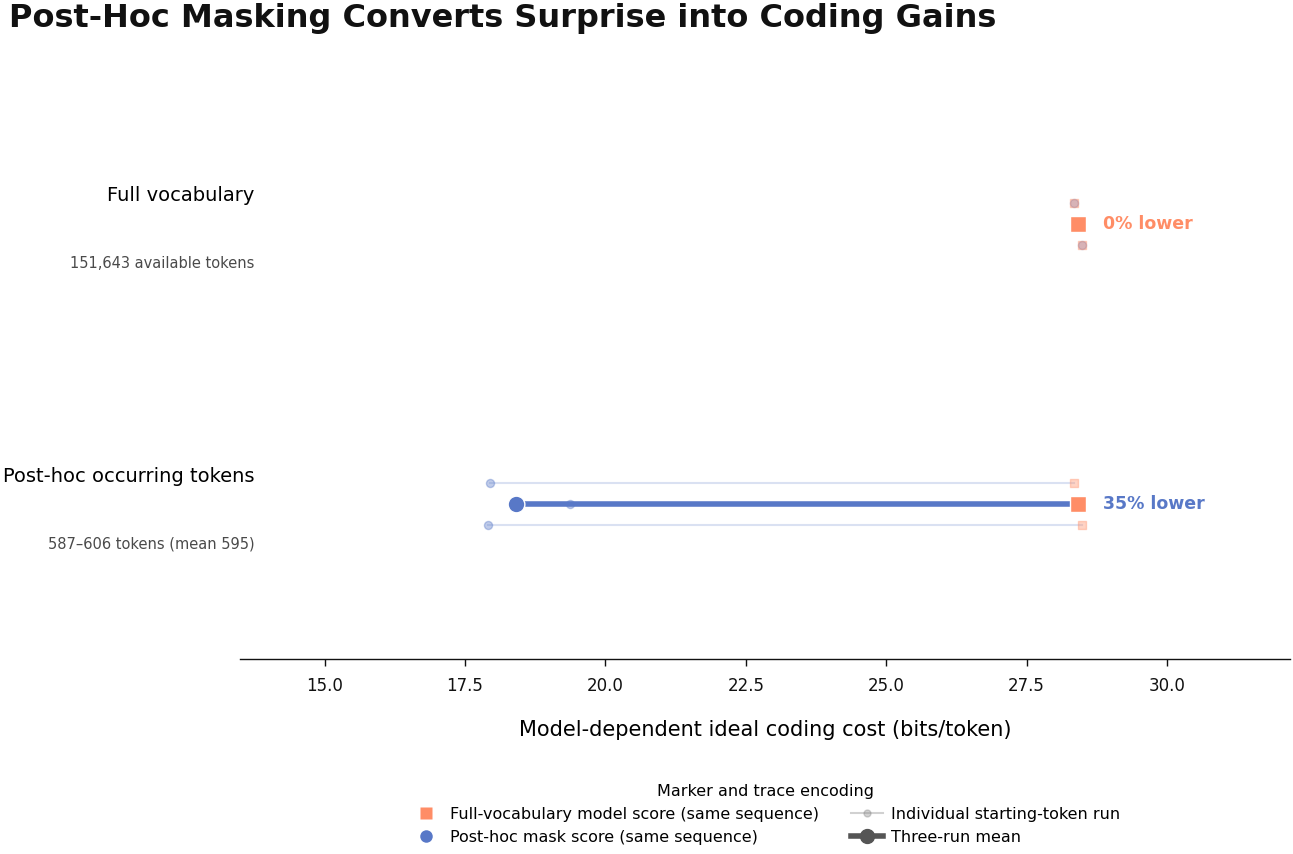

In [11]:
fig = plt.figure(figsize=(14, 8.3))
ax = fig.add_axes([0.19, 0.16, 0.75, 0.71])
editorial_title(fig, "Post-Hoc Masking Converts Surprise into Coding Gains")
display_order = ["full", "occurring"]
y_positions = {variant: 1 - index for index, variant in enumerate(display_order)}

for variant in display_order:
    subset = runs[runs["variant"] == variant]
    mean_row = summary[summary["variant"] == variant].iloc[0]
    y = y_positions[variant]
    offsets = np.linspace(-0.075, 0.075, len(subset))
    for (_, row), offset in zip(subset.iterrows(), offsets):
        ax.plot(
            [row["masked_bits_per_token"], row["model_bits_per_token"]],
            [y + offset, y + offset],
            color=VARIANT_COLORS[variant], alpha=0.22, linewidth=1.5, zorder=1,
        )
        ax.scatter(
            row["masked_bits_per_token"], y + offset,
            s=34, color=COLORS["blue"], alpha=0.38, zorder=2,
        )
        ax.scatter(
            row["model_bits_per_token"], y + offset,
            s=34, marker="s", color=COLORS["coral"], alpha=0.38, zorder=2,
        )

    ax.plot(
        [mean_row["masked_bits_mean"], mean_row["model_bits_mean"]], [y, y],
        color=VARIANT_COLORS[variant], linewidth=4.0, solid_capstyle="round", zorder=3,
    )
    ax.scatter(
        mean_row["masked_bits_mean"], y,
        s=145, color=COLORS["blue"], edgecolor="white", linewidth=1.0, zorder=4,
    )
    ax.scatter(
        mean_row["model_bits_mean"], y,
        s=130, marker="s", color=COLORS["coral"],
        edgecolor="white", linewidth=1.0, zorder=4,
    )
    dictionary_sizes = subset["dictionary_size"].astype(int)
    if dictionary_sizes.nunique() == 1:
        token_space_label = f"{dictionary_sizes.iloc[0]:,} available tokens"
    else:
        token_space_label = (
            f"{dictionary_sizes.min():,}–{dictionary_sizes.max():,} tokens "
            f"(mean {dictionary_sizes.mean():.0f})"
        )
    ax.text(
        13.75, y + 0.10, DISPLAY_NAMES[variant],
        ha="right", va="center", fontsize=14,
    )
    ax.text(
        13.75, y - 0.14, token_space_label,
        ha="right", va="center", fontsize=10.5, color=COLORS["muted"],
    )
    label_x = max(mean_row["model_bits_mean"], mean_row["masked_bits_mean"]) + 0.45
    ax.text(
        label_x, y,
        f"{mean_row['mask_gain_percent']:.0f}% lower",
        ha="left", va="center", fontsize=12.5,
        color=VARIANT_COLORS[variant], fontweight="bold",
    )

ax.set_xlim(13.5, 32.2)
ax.set_ylim(-0.55, 1.55)
ax.set_yticks([])
ax.set_xlabel("Model-dependent ideal coding cost (bits/token)", labelpad=18)
clean_axes(ax, keep_left=False)
legend_items = [
    Line2D([0], [0], marker="s", color="none", markerfacecolor=COLORS["coral"],
           markeredgecolor="none", markersize=9, label="Full-vocabulary model score (same sequence)"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=COLORS["blue"],
           markeredgecolor="none", markersize=9, label="Post-hoc mask score (same sequence)"),
    Line2D([0], [0], marker="o", color="#888888", linewidth=1.5,
           markerfacecolor="#888888", markersize=5, alpha=0.38, label="Individual starting-token run"),
    Line2D([0], [0], marker="o", color="#555555", linewidth=4.0,
           markerfacecolor="#555555", markersize=10, label="Three-run mean"),
]
ax.legend(
    handles=legend_items, loc="lower center", bbox_to_anchor=(0.5, -0.34),
    ncol=2, frameon=False, title="Marker and trace encoding",
    fontsize=11.5, title_fontsize=11.5, handletextpad=0.5, columnspacing=2.0,
)
save_figure(fig, "adversarial_masking_effect")
plt.show()

### How the entropy metric is calculated

Let $x_1,\ldots,x_N$ be a sequence of $N$ token IDs, where $x_t$ is the observed token at position $t$, and let $h_t=(x_1,\ldots,x_{t-1})$ be its preceding context. Let $V$ be the full tokenizer vocabulary, let $u$ and $v$ denote candidate token IDs in $V$, let $z_t(v)$ be the model logit for candidate $v$ after context $h_t$, and let $\theta$ denote the fixed model parameters. The model distribution is

$$
p_\theta(v\mid h_t)=\frac{\exp z_t(v)}{\sum_{u\in V}\exp z_t(u)}.
$$

For an allowed dictionary $D\subseteq V$, where $D$ is the set of token IDs retained by the global mask, the pipeline removes all logits outside $D$ and applies softmax again. Therefore the probability $q_\theta$ supplied to the arithmetic coder is

$$
q_\theta(v\mid h_t,D)=\frac{\exp z_t(v)}{\sum_{u\in D}\exp z_t(u)}
=\frac{p_\theta(v\mid h_t)}{\sum_{u\in D}p_\theta(u\mid h_t)},\qquad v\in D.
$$

The realized information content, or surprisal, $\ell_t(D)$ of the observed token $x_t$ under dictionary $D$ is

$$
\ell_t(D)=-\log_2 q_\theta(x_t\mid h_t,D).
$$

The pipeline accumulates this value over every predicted token. Here $L_D(x_{1:N})$ is the total surprisal of sequence $x_{1:N}$ under dictionary $D$, and $\bar L_D$ is the mean surprisal per predicted token:

$$
L_D(x_{1:N})=\sum_{t=2}^{N}-\log_2 q_\theta(x_t\mid h_t,D),\qquad
\bar L_D=\frac{L_D}{N-1}.
$$

The first token is a seed and is stored rather than predicted, so a single 1,000-token sequence has 999 terms. More generally, with $B$ independent batches, the denominator is $N-B$. In the implementation, `global_mask_compressor.py` accumulates `-log2(probability_of_actual_token)` in the legacy field named `entropy`. Thus this quantity is a **realized sequence cross-entropy / negative log-likelihood**, not the Shannon entropy

$$
H(q_t)=-\sum_{v\in D}q_t(v)\log_2 q_t(v),\qquad q_t(v)=q_\theta(v\mid h_t,D),
$$

which would average over every possible next token.

#### Full-vocabulary construction, then post-hoc rescoring

The adversarial sequence is constructed exactly once. Let $x_{1:t-1}=(x_1,\ldots,x_{t-1})$ denote the current token prefix, and let $C(x_{1:t-1})$ be the set of candidate token IDs $v$ that preserve canonical tokenization after appending $v$:

$$
C(x_{1:t-1})=\left\{v:\operatorname{encode}(\operatorname{decode}(x_{1:t-1},v))=(x_{1:t-1},v)\right\}.
$$

At every step, candidates are examined from lowest to highest full-vocabulary probability. The symbol $x_t^{\mathrm{worst}}$ denotes the selected adversarial token at position $t$:

$$
x_t^{\mathrm{worst}}=\arg\min_{v\in V\cap C(x_{1:t-1})}z_t(v)
=\arg\min_{v\in V\cap C(x_{1:t-1})}p_\theta(v\mid h_t).
$$

Because every starting sequence also round-trips, induction guarantees that every completed adversarial sequence is the canonical tokenization of its decoded UTF-8 text.

For run index $r$, the occurring-token dictionary $D_{\mathrm{occ}}^{(r)}$ is the set of distinct adversarial token IDs appearing in that completed run:

$$
D_{\mathrm{occ}}^{(r)}=\{x_t^{\mathrm{worst}}:1\leq t\leq N\}.
$$

The fixed sequence is then replayed through the model with the same contexts. Its full-vocabulary score uses $p_\theta$; its post-hoc occurring-token score uses $q_\theta(\cdot\mid h_t,D_{\mathrm{occ}}^{(r)})$. No token is regenerated after masking. Consequently, the orange squares for the two policies in the masking plot coincide: they are the same target tokens under the same original model distributions. Only the blue post-hoc score moves left because probability mass outside $D_{\mathrm{occ}}^{(r)}$ is removed and the retained probabilities are renormalized.

The plotted worst-case value is the mean of $\bar L_D$ across the three starting tokens; error bars are their sample standard deviation.

For the 100,000-token text8 runs with $B=16$, the notebook reads $L_D$ from the saved experiment and calculates

$$
\bar L_D=\frac{L_D}{100000-16}.
$$

The exact full-vocabulary and occurring-token values are reported in the generated comparison table below.

Arithmetic coding ideally approaches $L_D$, but the realized payload can differ because of finite-precision probabilities, coder state, and finalization. The stored-size comparison therefore reports these quantities separately:

$$
\text{payload bits/token}=\frac{8B_\mathrm{AC}}{N-B},\qquad
\text{total bits/source token}=\frac{8(B_\mathrm{AC}+B_\mathrm{bitmap})}{N}.
$$

Here $B_{\mathrm{AC}}$ is the arithmetic-coded payload size in bytes, $B_{\mathrm{bitmap}}$ is the dictionary bitmap size in bytes, $N$ is the total number of source tokens, and $B$ is the number of independently seeded batches. Thus $N-B$ tokens are predicted and arithmetic-coded. “Total” includes the occurring-token bitmap needed to reconstruct the dictionary.


### Worst case versus typical text8

The ideal per-token comparison uses the normal compression pipeline on the first 100,000 text8 tokens. It matches the adversarial setup on model, context length, retained context, and KV-cache policy. Text8 uses batch size 16 for practical runtime and to amortize dictionary overhead; the adversarial result remains three independent 1,000-token sequences. For the adversarial case, the occurring-token policy is a post-hoc rescore of the full-vocabulary worst-case sequence. For text8, each policy scores the same ordinary text directly.

The primary comparison is ideal bits per predicted token: pipeline sequence cross-entropy for text8 versus masked surprisal for the adversarial sequences. Realized AC payload and bitmap overhead are shown separately so implementation overhead is not confused with model surprise.

Reproduce the two pipeline runs from the repository root:

```bash
.venv/bin/python main.py --mode compress --input_path data/text8 \
  --model_name Qwen/Qwen2.5-0.5B --first_n_tokens 100000 \
  --context_length 1000 --retain_tokens 100 --batch_size 16 \
  --encoding AC --use_kv_cache --no_reduce_tokens --force \
  --output_path artifacts/runs/typical_text8/qwen_05b_n100000/full/compression_data.bin

.venv/bin/python main.py --mode compress --input_path data/text8 \
  --model_name Qwen/Qwen2.5-0.5B --first_n_tokens 100000 \
  --context_length 1000 --retain_tokens 100 --batch_size 16 \
  --encoding AC --use_kv_cache --reduce_tokens --force \
  --output_path artifacts/runs/typical_text8/qwen_05b_n100000/occurring/compression_data.bin
```


In [12]:
PIPELINE_RESULTS = ROOT / "artifacts" / "runs" / "current" / "compression_results.json"
assert PIPELINE_RESULTS.exists(), f"Missing pipeline results: {PIPELINE_RESULTS}"
pipeline_results = json.loads(PIPELINE_RESULTS.read_text(encoding="utf-8"))

matched_metadata = metadata_by_variant["full"]


def find_text8_result(*, reduce_tokens):
    matches = []
    for entry in pipeline_results.values():
        compression = entry.get("compression", {})
        args = compression.get("args", {})
        if (
            Path(str(args.get("input_path", ""))).name == "text8"
            and args.get("model_name") == matched_metadata["model_name"]
            and args.get("first_n_tokens") == 100_000
            and args.get("context_length") == matched_metadata["context_length"]
            and args.get("retain_tokens") == matched_metadata["retain_tokens"]
            and args.get("use_kv_cache") == matched_metadata["use_kv_cache"]
            and args.get("batch_size") == 16
            and args.get("encoding") == "AC"
            and args.get("reduce_tokens") is reduce_tokens
            and args.get("lora_path") is None
        ):
            matches.append(compression)
    policy = "occurring" if reduce_tokens else "full"
    assert len(matches) == 1, f"Expected one matched text8 {policy} result, found {len(matches)}"
    return matches[0]


comparison_rows = []
for variant, reduce_tokens in (("full", False), ("occurring", True)):
    typical = find_text8_result(reduce_tokens=reduce_tokens)
    predicted_tokens = typical["args"]["first_n_tokens"] - typical["args"]["batch_size"]
    worst = summary.loc[summary["variant"] == variant].iloc[0]
    typical_ideal = typical["entropy"] / predicted_tokens
    worst_ideal = worst["masked_bits_mean"]
    comparison_rows.append(
        {
            "variant": variant,
            "Dictionary policy": DISPLAY_NAMES[variant],
            "Typical cross-entropy bits/predicted token": typical_ideal,
            "Worst ideal bits/predicted token": worst_ideal,
            "Worst-case standard deviation": worst["masked_bits_std"],
            "Worst / typical": worst_ideal / typical_ideal,
            "Typical AC payload bits/predicted token": (
                typical["arithmetic_code_size_bytes"] * 8 / predicted_tokens
            ),
            "Typical total bits/source token": (
                typical["final_size_bytes"] * 8 / typical["args"]["first_n_tokens"]
            ),
            "Typical bitmap bytes": typical["bitmap_size_bytes"],
            "Typical compressed/raw UTF-8 percent": (
                100 * typical["final_size_bytes"] / typical["original_size_bytes"]
            ),
            "Typical compression factor": typical["compression_factor"],
        }
    )

comparison = pd.DataFrame(comparison_rows)
display(comparison.drop(columns="variant").round(3))


,Dictionary policy,Typical cross-entropy bits/predicted token,Worst ideal bits/predicted token,Worst-case standard deviation,Worst / typical,Typical AC payload bits/predicted token,Typical total bits/source token,Typical bitmap bytes,Typical compressed/raw UTF-8 percent,Typical compression factor
0,Full vocabulary,4.954,28.409,0.077,5.734,6.136,6.138,35.0,14.405,6.942
1,Post-hoc occurring tokens,4.835,18.402,0.833,3.806,4.860,5.724,10818.0,13.434,7.444


Adversarial: 3 × 1,000 tokens · text8: 100,000 tokens, batch size 16 · context 1,000.


Saved artifacts/figures/neurips/adversarial_worst_case/typical_vs_adversarial.png


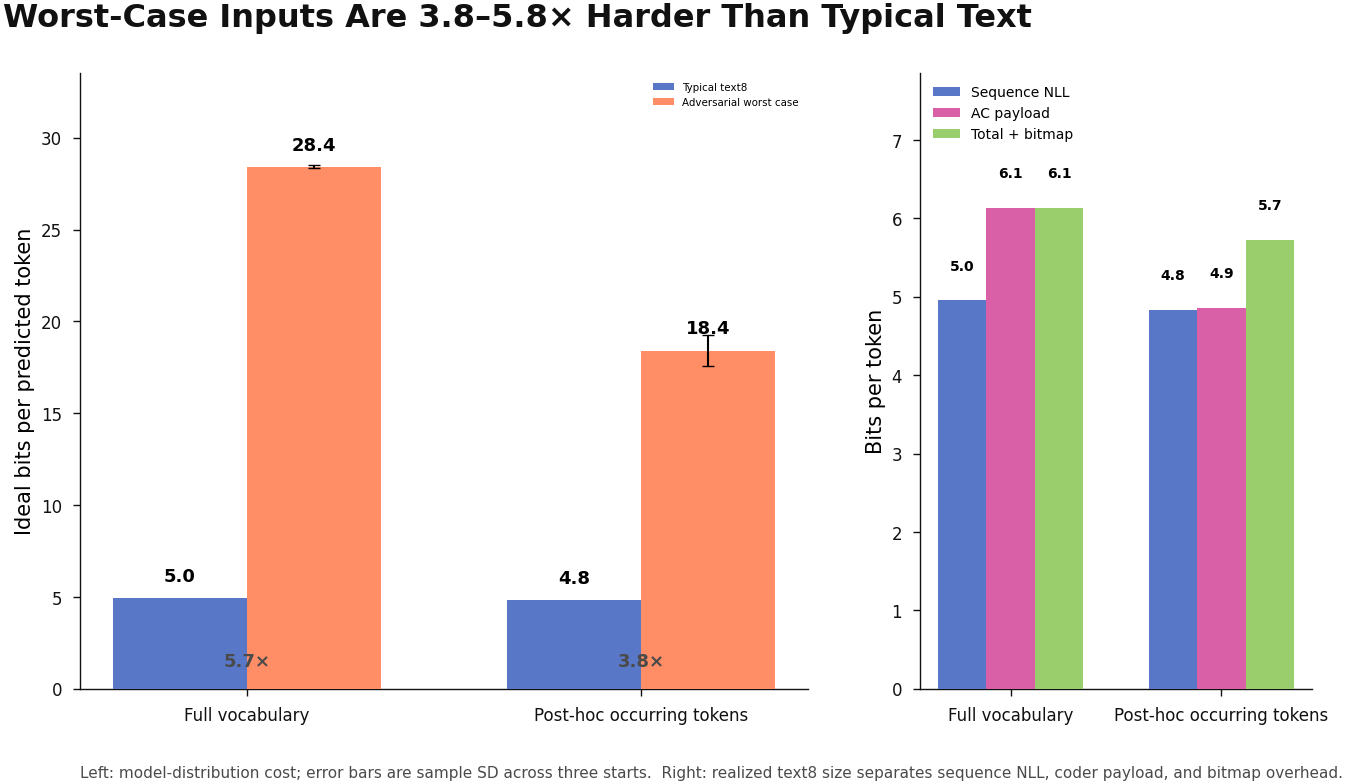

Saved artifacts/figures/neurips/adversarial_worst_case/typical_vs_adversarial_table.csv


In [13]:
fig = plt.figure(figsize=(14, 8.8))
left = fig.add_axes([0.08, 0.17, 0.52, 0.70])
right = fig.add_axes([0.68, 0.17, 0.28, 0.70])
editorial_title(fig, "Worst-Case Inputs Are 3.8–5.8× Harder Than Typical Text")
positions = np.arange(len(VARIANT_ORDER))
bar_width = 0.34
typical_positions = positions[:2] - bar_width / 2
worst_positions = positions + bar_width / 2

typical_values = comparison["Typical cross-entropy bits/predicted token"].to_numpy()
worst_values = summary.set_index("variant").loc[VARIANT_ORDER, "masked_bits_mean"].to_numpy()
worst_errors = summary.set_index("variant").loc[VARIANT_ORDER, "masked_bits_std"].to_numpy()

left.bar(
    typical_positions,
    typical_values,
    bar_width,
    color=COLORS["blue"],
    label="Typical text8",
    zorder=3,
)
left.bar(
    worst_positions,
    worst_values,
    bar_width,
    yerr=worst_errors,
    capsize=4,
    color=COLORS["coral"],
    label="Adversarial worst case",
    zorder=3,
)
for x, value in zip(typical_positions, typical_values):
    left.text(x, value + 0.7, f"{value:.1f}", ha="center", va="bottom", fontweight="bold")
for x, value in zip(worst_positions, worst_values):
    left.text(x, value + 0.7, f"{value:.1f}", ha="center", va="bottom", fontweight="bold")
for index, row in comparison.iterrows():
    left.text(
        positions[index],
        1.0,
        f"{row['Worst / typical']:.1f}×",
        ha="center",
        va="bottom",
        color=COLORS["muted"],
        fontweight="bold",
    )
left.set_xticks(positions, [DISPLAY_NAMES[variant] for variant in VARIANT_ORDER])
left.set_ylabel("Ideal bits per predicted token")
left.set_ylim(0, max(worst_values) * 1.18)
left.legend(frameon=False, loc="upper right")
clean_axes(left)

pipeline_measures = [
    ("Typical cross-entropy bits/predicted token", "Sequence NLL", COLORS["blue"]),
    ("Typical AC payload bits/predicted token", "AC payload", COLORS["pink"]),
    ("Typical total bits/source token", "Total + bitmap", COLORS["green"]),
]
pipeline_x = np.arange(2)
small_width = 0.23
for offset, (column, label, color) in zip((-1, 0, 1), pipeline_measures):
    values = comparison[column].to_numpy()
    bars = right.bar(
        pipeline_x + offset * small_width,
        values,
        small_width,
        color=color,
        label=label,
        zorder=3,
    )
    for bar, value in zip(bars, values):
        right.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.35,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )
right.set_xticks(pipeline_x, comparison["Dictionary policy"])
right.set_ylabel("Bits per token")
right.set_ylim(0, comparison["Typical total bits/source token"].max() * 1.28)
right.legend(frameon=False, fontsize=10, loc="upper left")
clean_axes(right)

fig.text(
    0.08,
    0.075,
    "Left: model-distribution cost; error bars are sample SD across three starts.  "
    "Right: realized text8 size separates sequence NLL, coder payload, and bitmap overhead.",
    ha="left",
    va="center",
    fontsize=11,
    color=COLORS["muted"],
)
save_figure(fig, "typical_vs_adversarial")
plt.show()

comparison_table = comparison.drop(columns="variant").copy()
comparison_table.to_csv(
    FIGURE_DIR / "typical_vs_adversarial_table.csv", index=False
)
print(f"Saved {(FIGURE_DIR / 'typical_vs_adversarial_table.csv').relative_to(ROOT)}")


### Predictability versus compression ratio

Qwen2.5-0.5B supplies the next-token probabilities. Let $x=(x_1,\ldots,x_N)$ be all $N$ tokens being evaluated, split into $B$ independently seeded sequences. For each predicted position $t$, $x_t$ is the observed token, $h_t$ is its preceding context, and $p_\theta(x_t\mid h_t)$ is the probability assigned by the fixed model with parameters $\theta$. Their mean full-vocabulary surprisal $S_{\mathrm{ref}}(x)$ is used as the predictability measure, with the sum taken over the $N-B$ predicted positions:

$$
S_{\mathrm{ref}}(x)=\frac{1}{N-B}\sum_t-\log_2 p_\theta(x_t\mid h_t).
$$

Lower $S_{\mathrm{ref}}$ means more predictable text; the horizontal axis is therefore reversed so predictability increases from left to right. The occurring-token mask is deliberately **not** used for this coordinate, because it is derived from the completed sequence.

For text8, the vertical axis now uses the repository's standard raw UTF-8 denominator. Let $U_{\mathrm{UTF8}}$ be the uncompressed input size in bytes, let $C$ be the compressed size in bits, and let $\rho$ be the compressed size as a percentage of the original size:

$$
\rho=100\frac{C}{8U_{\mathrm{UTF8}}}\%,
$$

Thus lower $\rho$ is better and the repository's compression factor is $100/\rho$. Let $D$ be the dictionary used for coding and let $S_D$ be the mean surprisal, in bits per predicted token, after probabilities are restricted and renormalized over $D$. The model-induced minimum coded size $C_{\min,D}$ and its corresponding percentage $\rho_{\min,D}$—excluding dictionary transmission and finite-coder overhead—are

$$
C_{\min,D}=Bb+(N-B)S_D,
\qquad
\rho_{\min,D}=100\frac{Bb+(N-B)S_D}{8U_{\mathrm{UTF8}}}\%,
$$

Here $V$ is the full vocabulary, $|V|$ is its number of token IDs, and $b=\lceil\log_2|V|\rceil$ is the fixed-width cost in bits of storing one initial token. Each of the $B$ sequences contributes one such initial token; the remaining $N-B$ tokens are coded at an average cost $S_D$. This is a lower bound for a code constrained to the stated model probabilities, not a universal lower bound for an individual sequence. For the full-vocabulary points, $D=V$ and $S_D=S_{\mathrm{ref}}$.

For post-hoc occurring-token rescoring, let $D_{\mathrm{occ}}$ be the set of distinct token IDs occurring in the completed sequence and let $S_{\mathrm{occ}}$ be its mean surprisal after renormalization over that set. With $u$ denoting a candidate token ID in $D_{\mathrm{occ}}$, and with the sum taken over the same $N-B$ predicted positions,

$$
S_{\mathrm{occ}}=S_{\mathrm{ref}}+\frac{1}{N-B}\sum_t
\log_2\!\left(\sum_{u\in D_{\mathrm{occ}}}p_\theta(u\mid h_t)\right),
$$

so its reduction depends on the probability mass retained by each sequence-specific mask. Dictionary transmission is excluded from these entropy-only points; realized text8 crosses include the arithmetic-coded payload and bitmap.

The adversarial generator now enforces $\operatorname{encode}(\operatorname{decode}(x))=x$ after every extension. Its denominator is therefore the measured UTF-8 byte length of its own decoded input, not a projection from text8. The coral points remain entropy-only floors because the adversarial inputs have not yet been passed through the arithmetic coder; the gold text8 points are realized totals.


Saved artifacts/figures/neurips/adversarial_worst_case/predictability_vs_compression.png


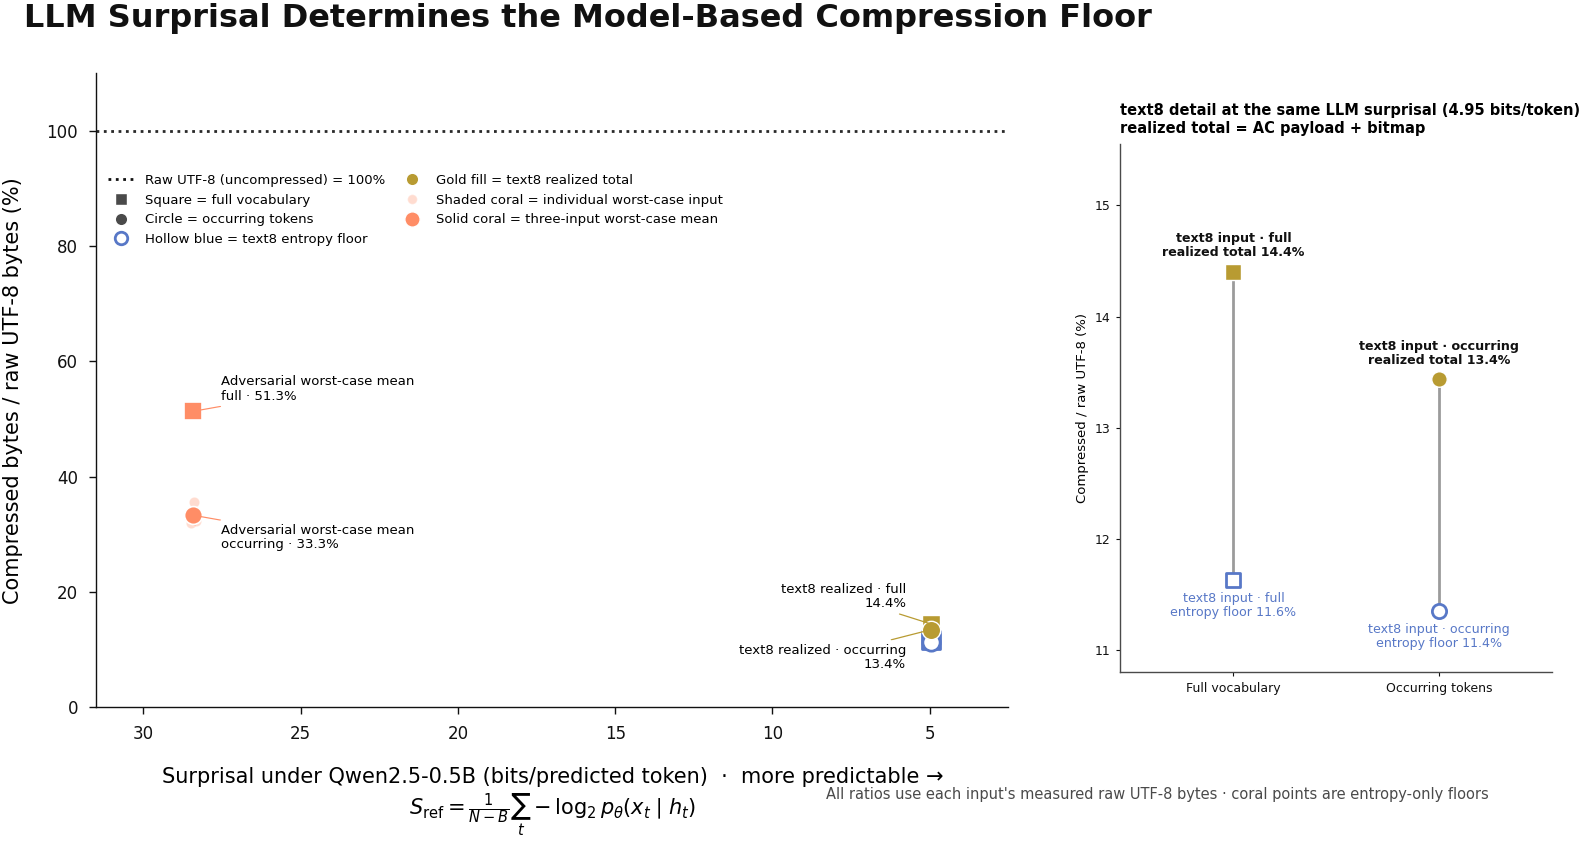

,dataset,variant,normalization,reference_surprisal,coding_surprisal,minimum_size_ratio_percent
0,Adversarial worst case,full,measured round-tripping raw UTF-8 bytes,28.409,28.409,51.346
1,Adversarial worst case,occurring,measured round-tripping raw UTF-8 bytes,28.409,18.402,33.284
2,Typical text8,full,measured raw UTF-8 bytes,4.954,4.954,11.631
3,Typical text8,occurring,measured raw UTF-8 bytes,4.954,4.835,11.352


,dataset,variant,reference_surprisal,realized_size_ratio_percent
0,Typical text8,full,4.954,14.405
1,Typical text8,occurring,4.954,13.434


In [14]:
vocab_size = int(runs.loc[runs["variant"] == "full", "dictionary_size"].iloc[0])
fixed_width_bits = int(np.ceil(np.log2(vocab_size)))
text8_results = {
    "full": find_text8_result(reduce_tokens=False),
    "occurring": find_text8_result(reduce_tokens=True),
}

text8_total_tokens = text8_results["full"]["args"]["first_n_tokens"]
text8_batches = text8_results["full"]["args"]["batch_size"]
text8_predicted_tokens = text8_total_tokens - text8_batches
raw_utf8_bytes = text8_results["full"]["original_size_bytes"]
assert text8_results["occurring"]["original_size_bytes"] == raw_utf8_bytes
raw_utf8_bits = 8 * raw_utf8_bytes

text8_reference_surprisal = float(
    comparison.loc[
        comparison["variant"] == "full",
        "Typical cross-entropy bits/predicted token",
    ].iloc[0]
)

limit_rows = []
for _, row in comparison.iterrows():
    floor_bits = (
        text8_batches * fixed_width_bits
        + text8_predicted_tokens * row["Typical cross-entropy bits/predicted token"]
    )
    limit_rows.append(
        {
            "dataset": "Typical text8",
            "variant": row["variant"],
            "run_index": 0,
            "reference_surprisal": text8_reference_surprisal,
            "coding_surprisal": row["Typical cross-entropy bits/predicted token"],
            "minimum_size_ratio_percent": 100 * floor_bits / raw_utf8_bits,
            "normalization": "measured raw UTF-8 bytes",
        }
    )
for _, row in runs.iterrows():
    adversarial_tokens = int(row["total_tokens"])
    adversarial_predicted = adversarial_tokens - 1
    adversarial_raw_utf8_bits = 8 * int(row["decoded_utf8_size_bytes"])
    floor_bits = (
        fixed_width_bits
        + adversarial_predicted * row["masked_bits_per_token"]
    )
    limit_rows.append(
        {
            "dataset": "Adversarial worst case",
            "variant": str(row["variant"]),
            "run_index": int(row["run_index"]),
            "reference_surprisal": row["model_bits_per_token"],
            "coding_surprisal": row["masked_bits_per_token"],
            "minimum_size_ratio_percent": 100 * floor_bits / adversarial_raw_utf8_bits,
            "normalization": "measured round-tripping raw UTF-8 bytes",
        }
    )
predictability_limits = pd.DataFrame(limit_rows)

realized_ratios = pd.DataFrame(
    [
        {
            "dataset": "Typical text8",
            "variant": variant,
            "reference_surprisal": text8_reference_surprisal,
            "realized_size_ratio_percent": (
                100 * result["final_size_bytes"] / result["original_size_bytes"]
            ),
        }
        for variant, result in text8_results.items()
    ]
)

fig = plt.figure(figsize=(16, 8.8))
ax = fig.add_axes([0.07, 0.15, 0.57, 0.72])
editorial_title(fig, "LLM Surprisal Determines the Model-Based Compression Floor")

# Raw UTF-8 is independent of model surprisal and therefore spans the plot.
ax.axhline(
    100, color=COLORS["ink"], linewidth=2.0, linestyle=":", alpha=0.90, zorder=1,
)

policy_markers = {"full": "s", "occurring": "o"}
dataset_colors = {"Typical text8": COLORS["blue"], "Adversarial worst case": COLORS["coral"]}
adversarial_mean_labels = []
for (dataset, variant), subset in predictability_limits.groupby(["dataset", "variant"]):
    color = dataset_colors[dataset]
    marker = policy_markers[variant]
    if dataset == "Adversarial worst case":
        ax.scatter(
            subset["reference_surprisal"], subset["minimum_size_ratio_percent"],
            s=55, marker=marker, color=color, alpha=0.30,
            edgecolor="white", linewidth=0.7, zorder=3,
        )
        mean_x = subset["reference_surprisal"].mean()
        mean_y = subset["minimum_size_ratio_percent"].mean()
        ax.scatter(
            mean_x, mean_y, s=165, marker=marker, color=color,
            edgecolor="white", linewidth=1.2, zorder=5,
        )
        policy_name = "full" if variant == "full" else "occurring"
        label_y_offset = 16 if variant == "full" else -16
        adversarial_mean_labels.append(ax.annotate(
            f"Adversarial worst-case mean\n{policy_name} · {mean_y:.1f}%",
            (mean_x, mean_y),
            xytext=(20, label_y_offset), textcoords="offset points",
            ha="left", va="center", fontsize=9.5, linespacing=1.15,
            bbox={"boxstyle": "round,pad=0.24", "facecolor": "white", "edgecolor": "none", "alpha": 0.88},
            arrowprops={"arrowstyle": "-", "color": color, "linewidth": 0.85},
            zorder=6,
        ))
    else:
        ax.scatter(
            subset["reference_surprisal"].mean(), subset["minimum_size_ratio_percent"].mean(),
            s=155, marker=marker, facecolor="white", edgecolor=COLORS["blue"],
            linewidth=2.0, zorder=4,
        )

text8_realized_labels = []
for _, realized in realized_ratios.iterrows():
    limit = predictability_limits[
        (predictability_limits["dataset"] == "Typical text8")
        & (predictability_limits["variant"] == realized["variant"])
    ].iloc[0]
    x = realized["reference_surprisal"]
    y_min = limit["minimum_size_ratio_percent"]
    y_actual = realized["realized_size_ratio_percent"]
    ax.plot([x, x], [y_min, y_actual], color=COLORS["muted"], alpha=0.45, linewidth=1.5)
    ax.scatter(
        x, y_actual, s=175, marker=policy_markers[realized["variant"]],
        color=COLORS["gold"], edgecolor="white", linewidth=1.0, zorder=5,
    )
    policy_name = "full" if realized["variant"] == "full" else "occurring"
    label_y_offset = 20 if realized["variant"] == "full" else -20
    text8_realized_labels.append(ax.annotate(
        f"text8 realized · {policy_name}\n{y_actual:.1f}%",
        (x, y_actual),
        xytext=(-18, label_y_offset), textcoords="offset points",
        ha="right", va="center", fontsize=9.5, linespacing=1.15,
        bbox={"boxstyle": "round,pad=0.24", "facecolor": "white", "edgecolor": "none", "alpha": 0.90},
        arrowprops={"arrowstyle": "-", "color": COLORS["gold"], "linewidth": 0.9},
        zorder=6,
    ))

text8_full_min = predictability_limits.query(
    'dataset == "Typical text8" and variant == "full"'
).iloc[0]
text8_occ_min = predictability_limits.query(
    'dataset == "Typical text8" and variant == "occurring"'
).iloc[0]
text8_full_actual = realized_ratios.query('variant == "full"').iloc[0]
text8_occ_actual = realized_ratios.query('variant == "occurring"').iloc[0]
adv_means = (
    predictability_limits.query('dataset == "Adversarial worst case"')
    .groupby("variant").mean(numeric_only=True)
)

callouts = []

ax.set_xlim(31.5, 2.5)
ax.set_ylim(
    0,
    max(
        110,
        predictability_limits["minimum_size_ratio_percent"].max() * 1.13,
    ),
)
ax.set_xlabel(
    "Surprisal under Qwen2.5-0.5B (bits/predicted token)  ·  more predictable →\n"
    r"$S_{\mathrm{ref}}=\frac{1}{N-B}\sum_t -\log_2 p_\theta(x_t\mid h_t)$",
    labelpad=17,
)
ax.set_ylabel("Compressed bytes / raw UTF-8 bytes (%)", labelpad=17)
clean_axes(ax)

# A separate right-hand detail panel separates policies without changing
# their shared full-vocabulary surprisal coordinate in the main axes.
detail = fig.add_axes([0.71, 0.19, 0.27, 0.60])
detail.set_facecolor("white")
detail.patch.set_alpha(0.97)
policy_x = {"full": 0, "occurring": 1}
detail_labels = []
for variant in ("full", "occurring"):
    floor_row = predictability_limits.query(
        'dataset == "Typical text8" and variant == @variant'
    ).iloc[0]
    realized_row = realized_ratios.query('variant == @variant').iloc[0]
    x = policy_x[variant]
    floor_value = float(floor_row["minimum_size_ratio_percent"])
    realized_value = float(realized_row["realized_size_ratio_percent"])
    detail.plot(
        [x, x], [floor_value, realized_value],
        color=COLORS["muted"], alpha=0.55, linewidth=2.0, zorder=1,
    )
    detail.scatter(
        x, floor_value, s=105, marker=policy_markers[variant],
        facecolor="white", edgecolor=COLORS["blue"], linewidth=2.0, zorder=3,
    )
    detail.scatter(
        x, realized_value, s=125, marker=policy_markers[variant],
        color=COLORS["gold"], edgecolor="white", linewidth=1.0, zorder=4,
    )
    policy_label = "full" if variant == "full" else "occurring"
    detail_labels.append(detail.annotate(
        f"text8 input · {policy_label}\nentropy floor {floor_value:.1f}%",
        (x, floor_value), xytext=(0, -9), textcoords="offset points",
        ha="center", va="top", fontsize=9.1, color=COLORS["blue"], linespacing=1.1,
    ))
    detail_labels.append(detail.annotate(
        f"text8 input · {policy_label}\nrealized total {realized_value:.1f}%",
        (x, realized_value), xytext=(0, 9), textcoords="offset points",
        ha="center", va="bottom", fontsize=9.1, color=COLORS["ink"],
        fontweight="bold", linespacing=1.1,
    ))

detail.set_title(
    f"text8 detail at the same LLM surprisal ({text8_reference_surprisal:.2f} bits/token)\n"
    "realized total = AC payload + bitmap",
    fontsize=10.5, loc="left", pad=8,
)
detail.set_xlim(-0.55, 1.55)
detail.set_ylim(
    predictability_limits.query('dataset == "Typical text8"')["minimum_size_ratio_percent"].min() - 0.55,
    realized_ratios["realized_size_ratio_percent"].max() + 1.15,
)
detail.set_xticks([0, 1], ["Full vocabulary", "Occurring tokens"])
detail.set_ylabel("Compressed / raw UTF-8 (%)", fontsize=9.5)
detail.tick_params(axis="both", labelsize=9, length=3, pad=4)
detail.spines["top"].set_visible(False)
detail.spines["right"].set_visible(False)
detail.spines["left"].set_color(COLORS["muted"])
detail.spines["bottom"].set_color(COLORS["muted"])

legend_items = [
    Line2D([0], [0], color=COLORS["ink"], linewidth=2.0, linestyle=":",
           label="Raw UTF-8 (uncompressed) = 100%"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor=COLORS["muted"],
           markeredgecolor="white", markersize=9, label="Square = full vocabulary"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=COLORS["muted"],
           markeredgecolor="white", markersize=9, label="Circle = occurring tokens"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="white",
           markeredgecolor=COLORS["blue"], markeredgewidth=2, markersize=9,
           label="Hollow blue = text8 entropy floor"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=COLORS["gold"],
           markeredgecolor="white", markersize=9,
           label="Gold fill = text8 realized total"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=COLORS["coral"],
           markeredgecolor="white", markersize=7, alpha=0.30,
           label="Shaded coral = individual worst-case input"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=COLORS["coral"],
           markeredgecolor="white", markersize=11,
           label="Solid coral = three-input worst-case mean"),
]
main_legend = ax.legend(
    handles=legend_items, frameon=False, loc="upper left",
    bbox_to_anchor=(0.0, 0.86), ncol=2, fontsize=9.5, columnspacing=1.0,
)
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
axes_box = ax.get_window_extent(renderer=renderer)
for label in [
    *callouts, *adversarial_mean_labels, *text8_realized_labels,
]:
    label_box = label.get_window_extent(renderer=renderer)
    assert axes_box.contains(label_box.x0, label_box.y0)
    assert axes_box.contains(label_box.x1, label_box.y1)
legend_box = main_legend.get_window_extent(renderer=renderer)
assert axes_box.contains(legend_box.x0, legend_box.y0)
assert axes_box.contains(legend_box.x1, legend_box.y1)
detail_box = detail.get_window_extent(renderer=renderer)
assert not axes_box.overlaps(detail_box)
mean_label_boxes = [
    label.get_bbox_patch().get_window_extent(renderer=renderer)
    for label in adversarial_mean_labels
]
assert not mean_label_boxes[0].overlaps(mean_label_boxes[1])
text8_realized_boxes = [
    label.get_bbox_patch().get_window_extent(renderer=renderer)
    for label in text8_realized_labels
]
assert not text8_realized_boxes[0].overlaps(text8_realized_boxes[1])
for label in detail_labels:
    label_box = label.get_window_extent(renderer=renderer)
    assert detail_box.contains(label_box.x0, label_box.y0)
    assert detail_box.contains(label_box.x1, label_box.y1)
fig.text(
    0.94, 0.045,
    "All ratios use each input's measured raw UTF-8 bytes · coral points are entropy-only floors",
    ha="right", fontsize=10.5, color=COLORS["muted"],
)
save_figure(fig, "predictability_vs_compression")
plt.show()

display(
    predictability_limits.groupby(["dataset", "variant", "normalization"], as_index=False)
    .agg(
        reference_surprisal=("reference_surprisal", "mean"),
        coding_surprisal=("coding_surprisal", "mean"),
        minimum_size_ratio_percent=("minimum_size_ratio_percent", "mean"),
    )
    .round(3)
)
display(realized_ratios.round(3))


### Submission table

Values are mean ± sample standard deviation across starting tokens. Dictionary storage and arithmetic-coder overhead are not included in these idealized surprisal measurements.

In [15]:
paper_table = summary.copy()
paper_table["Model bits/token"] = paper_table.apply(
    lambda row: f"{row['model_bits_mean']:.2f} ± {row['model_bits_std']:.2f}", axis=1
)
paper_table["Masked bits/token"] = paper_table.apply(
    lambda row: f"{row['masked_bits_mean']:.2f} ± {row['masked_bits_std']:.2f}", axis=1
)
paper_table["Mask reduction"] = paper_table["mask_gain_percent"].map(lambda value: f"{value:.1f}%")
paper_table = paper_table[
    ["variant_label", "dictionary_size", "distinct_tokens", "Model bits/token", "Masked bits/token", "Mask reduction"]
].rename(
    columns={
        "variant_label": "Variant",
        "dictionary_size": "Dictionary",
        "distinct_tokens": "Distinct used",
    }
)
display(paper_table)
paper_table.to_csv(FIGURE_DIR / "adversarial_summary_table.csv", index=False)
print(f"Saved {(FIGURE_DIR / 'adversarial_summary_table.csv').relative_to(ROOT)}")

,Variant,Dictionary,Distinct used,Model bits/token,Masked bits/token,Mask reduction
0,Full vocabulary,151643,595.0,28.41 ± 0.08,28.41 ± 0.08,0.0%
1,Post-hoc occurring tokens,595,595.0,28.41 ± 0.08,18.40 ± 0.83,35.2%


Saved artifacts/figures/neurips/adversarial_worst_case/adversarial_summary_table.csv


### Interpretation

- Lossless full-vocabulary adversarial inputs require about 28.4 ideal bits/token, 5.73× the 100,000-token text8 cost of 4.95 bits/token.
- Post-hoc occurring-token rescoring lowers the same adversarial sequences to about 18.4 ideal bits/token, 3.81× the text8 occurring-token cost of 4.84 bits/token.
- The three sequence-derived adversarial dictionaries contain 592, 606, and 587 available tokens. They are not used to construct new worst-case sequences.
- Every adversarial prefix is constrained to canonical tokenizer round trips; all completed sequences satisfy `encode(decode(token_ids)) == token_ids`.
- Relative to each adversarial input's own measured raw UTF-8 size, the mean model-entropy floor is approximately 51.3% for the full vocabulary and 33.3% after occurring-token rescoring. These are not yet realized arithmetic-coder sizes.
- Relative to raw UTF-8 bytes, the realized 100,000-token text8 size is 14.40% for the full vocabulary and 13.43% for occurring tokens, corresponding to 6.94× and 7.44× compression.
- At 100,000 tokens, the occurring-token bitmap contributes only 2.03% of raw UTF-8 size, so its entropy reduction outweighs its dictionary overhead.
- The identical raw model scores across both adversarial policies verify that token IDs and contexts are unchanged; only post-hoc mask renormalization creates the coding gain.


### Compression-oriented adversaries: first test

This first end-to-end test uses 32 tokenizer symbols, beam width 2, branch factor 4, and a 32-token context. All generated conditions preserve canonical tokenization; classical compressors receive the exact decoded UTF-8 bytes produced by each condition. These results validate the experiment and plotting path, but they are not a paper-scale search.

The one-byte alphabet is intentional: it removes tokenizer expansion as a confounder, so greedy minimum probability and greedy surprisal per byte form a mathematical sanity check and must agree. Beam search can still change the sequence-level objective because each choice changes future distributions. The actual-ratio beam ranks cloned arithmetic-coder states including the 2,783 fixed bits measured from the verified 1,000-token serialized artifact. At only 32 tokens, that fixed cost necessarily dominates the serialized total; entropy and payload are the meaningful first-test comparisons.

In [16]:
ATTACK_RUN_NAME = "qwen_05b_ascii_n32_smoke"
ATTACK_RUN_DIR = (
    ROOT / "artifacts" / "runs" / "compression-attacks" / ATTACK_RUN_NAME
)
ATTACK_RESULTS_PATH = ATTACK_RUN_DIR / "results.json"

assert ATTACK_RESULTS_PATH.exists(), f"Missing attack results: {ATTACK_RESULTS_PATH}"
with ATTACK_RESULTS_PATH.open(encoding="utf-8") as handle:
    attack_payload = json.load(handle)

attack_metadata = attack_payload["metadata"]
assert attack_metadata["model_name"] == "Qwen/Qwen2.5-0.5B"
assert attack_metadata["total_length"] == 32
assert attack_metadata["generation_alphabet"] == "ascii-bytes"
assert attack_metadata["beam_width"] == 2
assert attack_metadata["branch_factor"] == 4
assert attack_metadata["fixed_overhead_bits"] == 2783

condition_labels = {
    "random-token": "Random tokens",
    "min-probability": "Greedy min probability",
    "surprisal-per-byte": "Greedy surprisal / byte",
    "beam-surprisal-per-byte": "Beam surprisal / byte",
    "beam-actual-ratio": "Beam realized ratio",
    "ordinary-text8": "Ordinary text8",
    "random-printable-utf8": "Random UTF-8",
}
attack_records = []
for run in attack_payload["runs"]:
    baselines = run["classical_baselines"]
    attack_records.append({
        "condition": run["condition"],
        "label": condition_labels[run["condition"]],
        "tokens": len(run["token_ids"]),
        "source_bytes": run["decoded_utf8_size_bytes"],
        "entropy_floor_percent": 100 * run["model_entropy_ratio"],
        "arithmetic_payload_percent": 100 * run["arithmetic_payload_ratio"],
        "serialized_total_percent": 100 * run["serialized_compression_ratio"],
        "gzip_9_percent": 100 * baselines["gzip-9"]["compression_ratio"],
        "zstd_22_percent": 100 * baselines["zstd-22"]["compression_ratio"],
        "brotli_11_percent": 100 * baselines["brotli-11"]["compression_ratio"],
    })

attack_results = pd.DataFrame(attack_records)
attack_order = list(condition_labels)
attack_results["condition"] = pd.Categorical(
    attack_results["condition"], categories=attack_order, ordered=True
)
attack_results = attack_results.sort_values("condition").reset_index(drop=True)
assert attack_results["condition"].notna().all()
assert len(attack_results) == len(attack_order)

attack_table = attack_results.drop(columns="condition").round(2)
attack_table_path = FIGURE_DIR / "compression_oriented_attacks_table.csv"
attack_table.to_csv(attack_table_path, index=False)
print(f"Results: {ATTACK_RESULTS_PATH.relative_to(ROOT)}")
print(f"Saved {attack_table_path.relative_to(ROOT)}")
display(attack_table)

Results: artifacts/runs/compression-attacks/qwen_05b_ascii_n32_smoke/results.json
Saved artifacts/figures/neurips/adversarial_worst_case/compression_oriented_attacks_table.csv


,label,tokens,source_bytes,entropy_floor_percent,arithmetic_payload_percent,serialized_total_percent,gzip_9_percent,zstd_22_percent,brotli_11_percent
0,Random tokens,32,32,106.82,115.62,1202.73,162.50,128.12,112.50
1,Greedy min probability,32,32,135.48,143.36,1230.47,162.50,128.12,112.50
2,Greedy surprisal / byte,32,32,135.48,143.36,1230.47,162.50,128.12,112.50
3,Beam surprisal / byte,32,32,136.70,144.14,1231.25,162.50,128.12,112.50
4,Beam realized ratio,32,32,135.13,142.58,1229.69,162.50,128.12,112.50
5,Ordinary text8,32,183,10.79,12.84,202.94,72.13,67.76,48.09
6,Random UTF-8,32,42,85.64,95.24,923.51,147.62,121.43,109.52


Saved artifacts/figures/neurips/adversarial_worst_case/compression_oriented_attacks.png


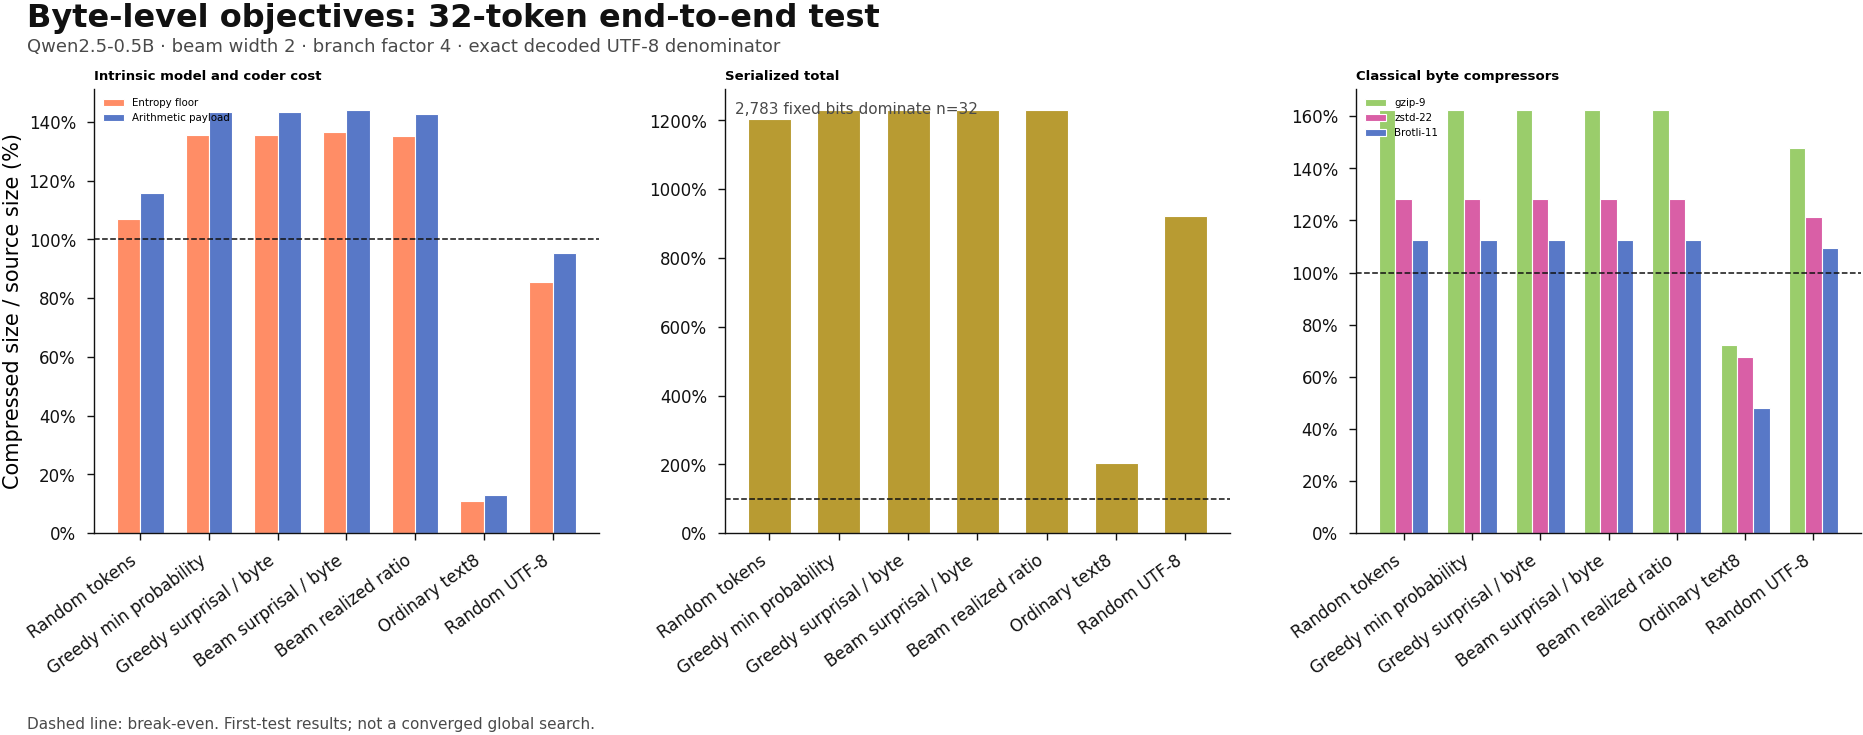

In [17]:
labels = attack_results["label"].tolist()
x = np.arange(len(labels))

fig, axes = plt.subplots(1, 3, figsize=(19, 7.8), gridspec_kw={"wspace": 0.25})
editorial_title(fig, "Byte-level objectives: 32-token end-to-end test")
fig.text(
    0.025, 0.905,
    "Qwen2.5-0.5B · beam width 2 · branch factor 4 · exact decoded UTF-8 denominator",
    ha="left", va="top", fontsize=13, color=COLORS["muted"],
)

width = 0.34
for offset, (name, column, color) in enumerate([
    ("Entropy floor", "entropy_floor_percent", COLORS["coral"]),
    ("Arithmetic payload", "arithmetic_payload_percent", COLORS["blue"]),
]):
    axes[0].bar(
        x + (offset - 0.5) * width, attack_results[column], width,
        label=name, color=color, edgecolor="white", linewidth=0.8,
    )
axes[0].set_title("Intrinsic model and coder cost", loc="left", fontweight="bold")
axes[0].set_ylabel("Compressed size / source size (%)")
axes[0].legend(frameon=False, loc="upper left")

axes[1].bar(
    x, attack_results["serialized_total_percent"], 0.62,
    color=COLORS["gold"], edgecolor="white", linewidth=0.8,
)
axes[1].set_title("Serialized total", loc="left", fontweight="bold")
axes[1].text(
    0.02, 0.97, "2,783 fixed bits dominate n=32",
    transform=axes[1].transAxes, ha="left", va="top",
    fontsize=11, color=COLORS["muted"],
)

classic_width = 0.24
for offset, (name, column, color) in enumerate([
    ("gzip-9", "gzip_9_percent", COLORS["green"]),
    ("zstd-22", "zstd_22_percent", COLORS["pink"]),
    ("Brotli-11", "brotli_11_percent", COLORS["blue"]),
]):
    axes[2].bar(
        x + (offset - 1) * classic_width, attack_results[column], classic_width,
        label=name, color=color, edgecolor="white", linewidth=0.8,
    )
axes[2].set_title("Classical byte compressors", loc="left", fontweight="bold")
axes[2].legend(frameon=False, loc="upper left")

for ax in axes:
    clean_axes(ax)
    ax.axhline(100, color=COLORS["ink"], linewidth=1.1, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=36, ha="right")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0f}%"))

fig.text(
    0.025, 0.015,
    "Dashed line: break-even. First-test results; not a converged global search.",
    ha="left", va="bottom", fontsize=11, color=COLORS["muted"],
)
fig.subplots_adjust(top=0.84, bottom=0.27, left=0.06, right=0.99)
save_figure(fig, "compression_oriented_attacks")
plt.show()

#### First-test observations

- The greedy minimum-probability and surprisal-per-byte attacks both reach a 135.5% entropy floor and 143.4% arithmetic payload, exactly as required when every candidate represents one byte.
- Sequence-level entropy beam search increases the entropy floor to 136.7% and the realized payload to 144.1%, showing that future distributions matter even when token lengths are fixed.
- With width 2, the actual-coder beam reaches 142.6% payload, slightly below the entropy beam. This is a useful negative result: a narrow beam optimizing finite-prefix coder state is not guaranteed to dominate the entropy proposal and should not yet be presented as converged.
- The random-token control already expands under arithmetic coding (115.6%), whereas ordinary text8 reaches 12.8% payload.
- Fixed serialization overhead makes the 32-token totals exceed 900% in most generated conditions. Those totals validate accounting, but they are not representative asymptotic compression ratios.
- On these tiny inputs, gzip, Zstandard, and Brotli are dominated by their own framing overhead. Brotli compresses the text8 control to 48.1% but expands the random-token and random-UTF-8 controls.